# Notebook 16 — Unimodal vs Multimodal Comparison

**Purpose:** Compare ECG-only, RESP-only, and Multimodal (ECG + RESP) feature sets
using subject-wise 5-fold cross-validation with three classifiers.

**Output files:**
- `results/tables/unimodal_vs_multimodal_comparison.csv`
- `results/tables/rf_full_metrics_by_modality.csv`
- `results/tables/modality_summary_best_model.csv`
- `results/figures/unimodal_vs_multimodal_f1.png`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
)
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
print("All imports OK")

All imports OK


In [ ]:
df = pd.read_csv("../data/processed/windows_features_engineered.csv")
df = df.rename(columns={"Subject": "subject_id", "Stress_State": "label"})
print(f"Shape: {df.shape}")
print(f"Subjects: {sorted(df['subject_id'].unique())}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")

Shape: (599, 13)
Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Label distribution:
label
0    417
1    182
Name: count, dtype: int64


In [ ]:
# Full multimodal feature set (9 features)
FEATURE_COLS_FULL = [
    "Mean_RR", "SDNN", "RMSSD", "Mean_HR",          # ECG/HRV features
    "Resp_Rate", "Resp_Variability",                   # RESP features
    "HRV_HR_Ratio", "Resp_Regularity", "Autonomic_Index"  # engineered features
]

# ECG-only feature set (6 features)
FEATURE_COLS_ECG = [
    "Mean_RR", "SDNN", "RMSSD", "Mean_HR",
    "HRV_HR_Ratio", "Autonomic_Index"
]

# RESP-only feature set (3 features)
FEATURE_COLS_RESP = [
    "Resp_Rate", "Resp_Variability", "Resp_Regularity"
]

print(f"ECG features  ({len(FEATURE_COLS_ECG)}): {FEATURE_COLS_ECG}")
print(f"RESP features ({len(FEATURE_COLS_RESP)}): {FEATURE_COLS_RESP}")
print(f"Full features ({len(FEATURE_COLS_FULL)}): {FEATURE_COLS_FULL}")

ECG features  (6): ['Mean_RR', 'SDNN', 'RMSSD', 'Mean_HR', 'HRV_HR_Ratio', 'Autonomic_Index']
RESP features (3): ['Resp_Rate', 'Resp_Variability', 'Resp_Regularity']
Full features (9): ['Mean_RR', 'SDNN', 'RMSSD', 'Mean_HR', 'Resp_Rate', 'Resp_Variability', 'HRV_HR_Ratio', 'Resp_Regularity', 'Autonomic_Index']


In [ ]:
def run_cv(df, feature_cols, modality_name):
    """
    Runs subject-wise 5-fold CV for 3 models on given feature_cols.
    Returns a summary dict: {model_name: {metric: (mean, std)}}
    """
    # Extract arrays
    X_full   = df[feature_cols].values
    y_full   = df["label"].values
    subjects = df["subject_id"].values
    unique_subjects = np.unique(subjects)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "SVM (RBF Kernel)"   : SVC(kernel="rbf", probability=True, random_state=42),
        "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42),
    }

    fold_metrics = {
        name: {"accuracy":[], "precision":[], "recall":[], "f1":[],
               "roc_auc":[], "balanced_accuracy":[], "specificity":[]}
        for name in models
    }

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(unique_subjects), 1):
        train_subjects = unique_subjects[train_idx]
        test_subjects  = unique_subjects[test_idx]

        train_mask = np.isin(subjects, train_subjects)
        test_mask  = np.isin(subjects, test_subjects)

        X_train, y_train = X_full[train_mask], y_full[train_mask]
        X_test,  y_test  = X_full[test_mask],  y_full[test_mask]

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        for name, model in models.items():
            model_fresh = type(model)(**model.get_params())
            model_fresh.fit(X_train, y_train)
            y_pred = model_fresh.predict(X_test)
            y_prob = model_fresh.predict_proba(X_test)[:, 1]

            # Standard metrics
            acc   = accuracy_score(y_test, y_pred)
            prec  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
            rec   = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
            f1    = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
            try:
                roc = roc_auc_score(y_test, y_prob)
            except ValueError:
                roc = float("nan")
            bal_acc = balanced_accuracy_score(y_test, y_pred)

            # Specificity = TN / (TN + FP)
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            tn, fp = cm[0, 0], cm[0, 1]
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            fold_metrics[name]["accuracy"].append(acc)
            fold_metrics[name]["precision"].append(prec)
            fold_metrics[name]["recall"].append(rec)
            fold_metrics[name]["f1"].append(f1)
            fold_metrics[name]["roc_auc"].append(roc)
            fold_metrics[name]["balanced_accuracy"].append(bal_acc)
            fold_metrics[name]["specificity"].append(spec)

    # Aggregate
    summary = {}
    for name in models:
        summary[name] = {}
        for metric, vals in fold_metrics[name].items():
            arr = np.array(vals)
            summary[name][metric] = (round(np.nanmean(arr), 4), round(np.nanstd(arr), 4))

    print(f"\n=== {modality_name} ===")
    for name in models:
        f1_m, f1_s = summary[name]["f1"]
        roc_m, roc_s = summary[name]["roc_auc"]
        print(f"  {name}: F1={f1_m:.3f}\u00b1{f1_s:.3f}  AUC={roc_m:.3f}\u00b1{roc_s:.3f}")

    return summary

print("run_cv() defined")

run_cv() defined


In [ ]:
results_ecg        = run_cv(df, FEATURE_COLS_ECG,  "ECG Only")
results_resp       = run_cv(df, FEATURE_COLS_RESP, "RESP Only")
results_multimodal = run_cv(df, FEATURE_COLS_FULL, "Multimodal (ECG + RESP)")


=== ECG Only ===
  Logistic Regression: F1=0.498±0.152  AUC=0.796±0.104
  SVM (RBF Kernel): F1=0.572±0.242  AUC=0.840±0.082
  Random Forest: F1=0.576±0.193  AUC=0.822±0.082



=== RESP Only ===
  Logistic Regression: F1=0.431±0.164  AUC=0.798±0.078
  SVM (RBF Kernel): F1=0.407±0.184  AUC=0.731±0.065
  Random Forest: F1=0.495±0.089  AUC=0.729±0.066



=== Multimodal (ECG + RESP) ===
  Logistic Regression: F1=0.583±0.131  AUC=0.834±0.076
  SVM (RBF Kernel): F1=0.589±0.206  AUC=0.836±0.103
  Random Forest: F1=0.576±0.194  AUC=0.818±0.109


In [ ]:
# Build comparison table: F1 + ROC-AUC for all models across modalities
rows = []
model_names = ["Logistic Regression", "SVM (RBF Kernel)", "Random Forest"]
for name in model_names:
    ecg_f1_m, ecg_f1_s     = results_ecg[name]["f1"]
    ecg_auc_m, ecg_auc_s   = results_ecg[name]["roc_auc"]
    resp_f1_m, resp_f1_s   = results_resp[name]["f1"]
    resp_auc_m, resp_auc_s = results_resp[name]["roc_auc"]
    multi_f1_m, multi_f1_s   = results_multimodal[name]["f1"]
    multi_auc_m, multi_auc_s = results_multimodal[name]["roc_auc"]

    rows.append({
        "Model": name,
        "ECG_F1":  f"{ecg_f1_m:.3f}\u00b1{ecg_f1_s:.3f}",
        "ECG_AUC": f"{ecg_auc_m:.3f}\u00b1{ecg_auc_s:.3f}",
        "RESP_F1":  f"{resp_f1_m:.3f}\u00b1{resp_f1_s:.3f}",
        "RESP_AUC": f"{resp_auc_m:.3f}\u00b1{resp_auc_s:.3f}",
        "Multi_F1":  f"{multi_f1_m:.3f}\u00b1{multi_f1_s:.3f}",
        "Multi_AUC": f"{multi_auc_m:.3f}\u00b1{multi_auc_s:.3f}",
    })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv("../results/tables/unimodal_vs_multimodal_comparison.csv", index=False)
print("Saved: results/tables/unimodal_vs_multimodal_comparison.csv")
comparison_df

Saved: results/tables/unimodal_vs_multimodal_comparison.csv


,Model,ECG_F1,ECG_AUC,RESP_F1,RESP_AUC,Multi_F1,Multi_AUC
0,Logistic Regression,0.498±0.152,0.796±0.104,0.431±0.164,0.798±0.078,0.583±0.131,0.834±0.076
1,SVM (RBF Kernel),0.572±0.242,0.840±0.082,0.407±0.184,0.731±0.065,0.589±0.206,0.836±0.103
2,Random Forest,0.576±0.193,0.822±0.082,0.495±0.089,0.729±0.066,0.576±0.194,0.818±0.109


In [ ]:
# Full metrics table for Random Forest across all 3 modalities
METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc", "balanced_accuracy", "specificity"]
METRIC_LABELS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Balanced Accuracy", "Specificity"]

rf_rows = []
for metric, label in zip(METRICS, METRIC_LABELS):
    ecg_m, ecg_s     = results_ecg["Random Forest"][metric]
    resp_m, resp_s   = results_resp["Random Forest"][metric]
    multi_m, multi_s = results_multimodal["Random Forest"][metric]
    rf_rows.append({
        "Metric": label,
        "ECG_Only":    f"{ecg_m:.4f}\u00b1{ecg_s:.4f}",
        "RESP_Only":   f"{resp_m:.4f}\u00b1{resp_s:.4f}",
        "Multimodal":  f"{multi_m:.4f}\u00b1{multi_s:.4f}",
    })

rf_metrics_df = pd.DataFrame(rf_rows)
rf_metrics_df.to_csv("../results/tables/rf_full_metrics_by_modality.csv", index=False)
print("Saved: results/tables/rf_full_metrics_by_modality.csv")
rf_metrics_df

Saved: results/tables/rf_full_metrics_by_modality.csv


,Metric,ECG_Only,RESP_Only,Multimodal
0,Accuracy,0.7575±0.0944,0.7113±0.0575,0.7609±0.0876
1,Precision,0.5933±0.1341,0.5526±0.0897,0.5948±0.1412
2,Recall,0.5905±0.2494,0.4776±0.1275,0.5854±0.2423
3,F1,0.5758±0.1929,0.4948±0.0895,0.5764±0.1944
4,ROC-AUC,0.8222±0.0821,0.7286±0.0660,0.8175±0.1086
5,Balanced Accuracy,0.7102±0.1304,0.6455±0.0535,0.7113±0.1240
6,Specificity,0.8299±0.0855,0.8135±0.1024,0.8372±0.0795


Saved: results/figures/unimodal_vs_multimodal_f1.png


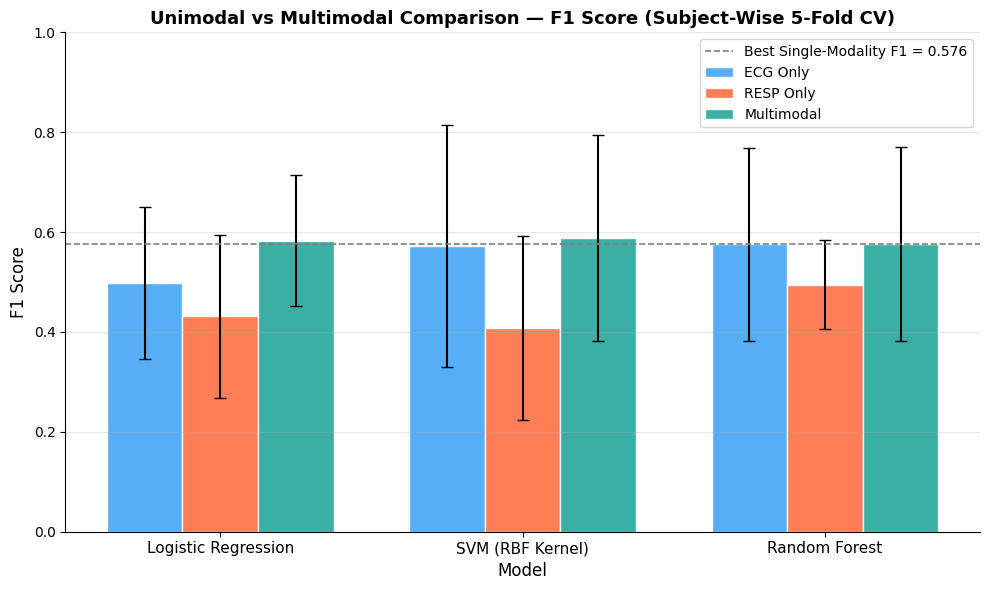

In [ ]:
# Grouped bar chart — F1 score for each model across 3 modalities
model_names = ["Logistic Regression", "SVM (RBF Kernel)", "Random Forest"]
modalities = ["ECG Only", "RESP Only", "Multimodal"]
colors = ["#42A5F5", "#FF7043", "#26A69A"]

f1_means = {
    "ECG Only":   [results_ecg[m]["f1"][0] for m in model_names],
    "RESP Only":  [results_resp[m]["f1"][0] for m in model_names],
    "Multimodal": [results_multimodal[m]["f1"][0] for m in model_names],
}
f1_stds = {
    "ECG Only":   [results_ecg[m]["f1"][1] for m in model_names],
    "RESP Only":  [results_resp[m]["f1"][1] for m in model_names],
    "Multimodal": [results_multimodal[m]["f1"][1] for m in model_names],
}

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (mod, color) in enumerate(zip(modalities, colors)):
    bars = ax.bar(x + i * width, f1_means[mod], width, yerr=f1_stds[mod],
                  label=mod, color=color, edgecolor="white", capsize=4, alpha=0.9)

# Best single-modality F1 (max mean F1 across ECG and RESP)
best_single_f1 = max(
    max(f1_means["ECG Only"]),
    max(f1_means["RESP Only"])
)
ax.axhline(y=best_single_f1, color="gray", linestyle="--", linewidth=1.2,
           label=f"Best Single-Modality F1 = {best_single_f1:.3f}")

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Unimodal vs Multimodal Comparison \u2014 F1 Score (Subject-Wise 5-Fold CV)", fontsize=13, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig("../results/figures/unimodal_vs_multimodal_f1.png", dpi=300, bbox_inches="tight")
print("Saved: results/figures/unimodal_vs_multimodal_f1.png")
plt.show()

In [ ]:
# Paper-ready modality summary — best model per modality
ALL_METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc", "balanced_accuracy", "specificity"]
METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Balanced Acc", "Specificity"]

modality_configs = [
    ("ECG Only",   results_ecg),
    ("RESP Only",  results_resp),
    ("ECG + RESP", results_multimodal),
]

summary_rows = []
for mod_name, results in modality_configs:
    # Find best model by F1
    best_model = max(results.keys(), key=lambda m: results[m]["f1"][0])
    row = {"Input Modality": mod_name, "Best Model": best_model}
    for metric, col_name in zip(ALL_METRICS, METRIC_COLS):
        m, s = results[best_model][metric]
        row[col_name] = f"{m:.3f}\u00b1{s:.3f}"
    summary_rows.append(row)

modality_summary_df = pd.DataFrame(summary_rows)
modality_summary_df.to_csv("../results/tables/modality_summary_best_model.csv", index=False)
print("Saved: results/tables/modality_summary_best_model.csv")
modality_summary_df

Saved: results/tables/modality_summary_best_model.csv


,Input Modality,Best Model,Accuracy,Precision,Recall,F1,ROC-AUC,Balanced Acc,Specificity
0,ECG Only,Random Forest,0.757±0.094,0.593±0.134,0.591±0.249,0.576±0.193,0.822±0.082,0.710±0.130,0.830±0.086
1,RESP Only,Random Forest,0.711±0.058,0.553±0.090,0.478±0.128,0.495±0.089,0.729±0.066,0.645±0.053,0.814±0.102
2,ECG + RESP,SVM (RBF Kernel),0.787±0.071,0.653±0.085,0.581±0.270,0.589±0.206,0.836±0.103,0.729±0.125,0.878±0.042


In [ ]:
# Auto-generate text comparing the three modalities for Results section
ecg_best  = max(results_ecg.keys(), key=lambda m: results_ecg[m]["f1"][0])
resp_best = max(results_resp.keys(), key=lambda m: results_resp[m]["f1"][0])
multi_best = max(results_multimodal.keys(), key=lambda m: results_multimodal[m]["f1"][0])

ecg_f1_m, ecg_f1_s       = results_ecg[ecg_best]["f1"]
ecg_auc_m, ecg_auc_s     = results_ecg[ecg_best]["roc_auc"]
resp_f1_m, resp_f1_s     = results_resp[resp_best]["f1"]
resp_auc_m, resp_auc_s   = results_resp[resp_best]["roc_auc"]
multi_f1_m, multi_f1_s   = results_multimodal[multi_best]["f1"]
multi_auc_m, multi_auc_s = results_multimodal[multi_best]["roc_auc"]

paragraph = (
    f"Using subject-wise 5-fold cross-validation on the WESAD dataset (15 subjects, 599 windows), "
    f"we compared three input modalities. "
    f"ECG-only features ({len(FEATURE_COLS_ECG)} features) achieved F1={ecg_f1_m:.3f}\u00b1{ecg_f1_s:.3f} "
    f"and AUC={ecg_auc_m:.3f}\u00b1{ecg_auc_s:.3f} with the best model ({ecg_best}). "
    f"RESP-only features ({len(FEATURE_COLS_RESP)} features) achieved F1={resp_f1_m:.3f}\u00b1{resp_f1_s:.3f} "
    f"and AUC={resp_auc_m:.3f}\u00b1{resp_auc_s:.3f} with the best model ({resp_best}). "
    f"Multimodal fusion ({len(FEATURE_COLS_FULL)} features) improved performance to "
    f"F1={multi_f1_m:.3f}\u00b1{multi_f1_s:.3f} and AUC={multi_auc_m:.3f}\u00b1{multi_auc_s:.3f} "
    f"with the best model ({multi_best}), demonstrating that combining ECG and respiratory signals "
    f"enhances binary stress classification."
)

print("=" * 80)
print("PAPER PARAGRAPH (Results section):")
print("=" * 80)
print(paragraph)

PAPER PARAGRAPH (Results section):
Using subject-wise 5-fold cross-validation on the WESAD dataset (15 subjects, 599 windows), we compared three input modalities. ECG-only features (6 features) achieved F1=0.576±0.193 and AUC=0.822±0.082 with the best model (Random Forest). RESP-only features (3 features) achieved F1=0.495±0.089 and AUC=0.729±0.066 with the best model (Random Forest). Multimodal fusion (9 features) improved performance to F1=0.589±0.206 and AUC=0.836±0.103 with the best model (SVM (RBF Kernel)), demonstrating that combining ECG and respiratory signals enhances binary stress classification.
